# Flight Dataset — Data Quality Check
Saint-Exupery Airport | `database.db`

## 1. Import libraries

In [24]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os, warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print('Libraries ready')

Libraries ready


In [25]:
OUT_DIR = Path(os.getcwd()) / 'outputs' / 'data_quality'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('Output folder:', OUT_DIR)

Output folder: c:\Users\ACER\Documents\GitHub\master-minds-challenge\outputs\data_quality


## 2. Load data

In [26]:
_here = Path(os.getcwd())
DB_PATH = _here / 'database.db'
if not DB_PATH.exists():
    DB_PATH = _here / 'database.db'

conn = sqlite3.connect(str(DB_PATH))
df_raw = pd.read_sql_query('SELECT * FROM mouvements_aero_insa', conn)
conn.close()
print(f'Loaded {len(df_raw):,} rows x {df_raw.shape[1]} columns')

Loaded 364,623 rows x 195 columns


## 3. Missing values

In [17]:

# ── Extended missing-value detection ──────────────────────────────────────────
# Covers: null/None/NaN  +  string placeholders stored as actual text
MISSING_STRINGS = {
    '', 'nan', 'NaN', 'NAN', 'null', 'NULL', 'Null',
    'none', 'None', 'NONE',
    'n/a', 'N/A', 'NA', 'na', 'N.A.', 'N.A', '#N/A', '#NA',
    '-', '--', '---', '?', '??',
    'unknown', 'Unknown', 'UNKNOWN',
    'nd', 'ND', 'n.d.', 'N.D.',
    'missing', 'MISSING',
}

def extended_missing_mask(series: pd.Series) -> pd.Series:
    """True where a value is missing: real null OR known string placeholder."""
    mask = series.isna()
    if series.dtype == object:
        str_mask = series.str.strip().str.lower().isin(
            {s.lower() for s in MISSING_STRINGS}
        )
        mask = mask | str_mask.fillna(False)
    return mask

print("Computing extended missing mask for all columns …")
ext_mask   = df_raw.apply(extended_missing_mask)          # bool DataFrame
null_count = df_raw.isna().sum()                          # strict null only
total_miss = ext_mask.sum()
str_only   = total_miss - null_count                       # string placeholders

missing = pd.DataFrame({
    'null_count'    : null_count,
    'str_missing'   : str_only,
    'total_missing' : total_miss,
    'total_%'       : (total_miss / len(df_raw) * 100).round(2),
}).sort_values('total_%', ascending=False)

any_miss = missing[missing['total_missing'] > 0]

print(f"\n{'Column':<40} {'null':>8} {'str_NA':>8} {'total':>8} {'total_%':>8}")
print('-' * 72)
for col, row in any_miss.iterrows():
    print(f"{col:<40} {row['null_count']:>8,} {row['str_missing']:>8,} "
          f"{row['total_missing']:>8,} {row['total_%']:>7.2f}%")

print(f"\n{'─'*72}")
print(f"Columns with ANY missing : {len(any_miss)} / {df_raw.shape[1]}")
print(f"  – via null/NaN         : {(null_count > 0).sum()}")
print(f"  – via string placeholder: {(str_only > 0).sum()}")
print(f"Rows with ANY missing    : {ext_mask.any(axis=1).sum():,}  "
      f"({ext_mask.any(axis=1).mean()*100:.1f}%)")


Computing extended missing mask for all columns …

Column                                       null   str_NA    total  total_%
------------------------------------------------------------------------
BusCauseModif                                 0.0 358,297.0 358,297.0   98.27%
PaymentReference                              0.0 353,748.0 353,748.0   97.02%
BusRotationSchedule                           0.0 353,752.0 353,752.0   97.02%
BusRotationActual                             0.0 353,750.0 353,750.0   97.02%
DelayMainReasonComment                        0.0 321,729.0 321,729.0   88.24%
PxAvgStrictDwelltime                          0.0 319,143.0 319,143.0   87.53%
PxAvgTimeBetweenCheckingPIF                   0.0 318,588.0 318,588.0   87.37%
PxAvgDwellTime                                0.0 318,408.0 318,408.0   87.33%
PxAvgTimeBetweenCtGSOBT                       0.0 318,408.0 318,408.0   87.33%
PxAvgTimeBetweenCtGGate                       0.0 318,347.0 318,347.0   87.31%
PxScansAc

Full missing report saved → c:\Users\ACER\Documents\GitHub\master-minds-challenge\outputs\data_quality\missing_report.csv
Plotting 90 affected column(s) …



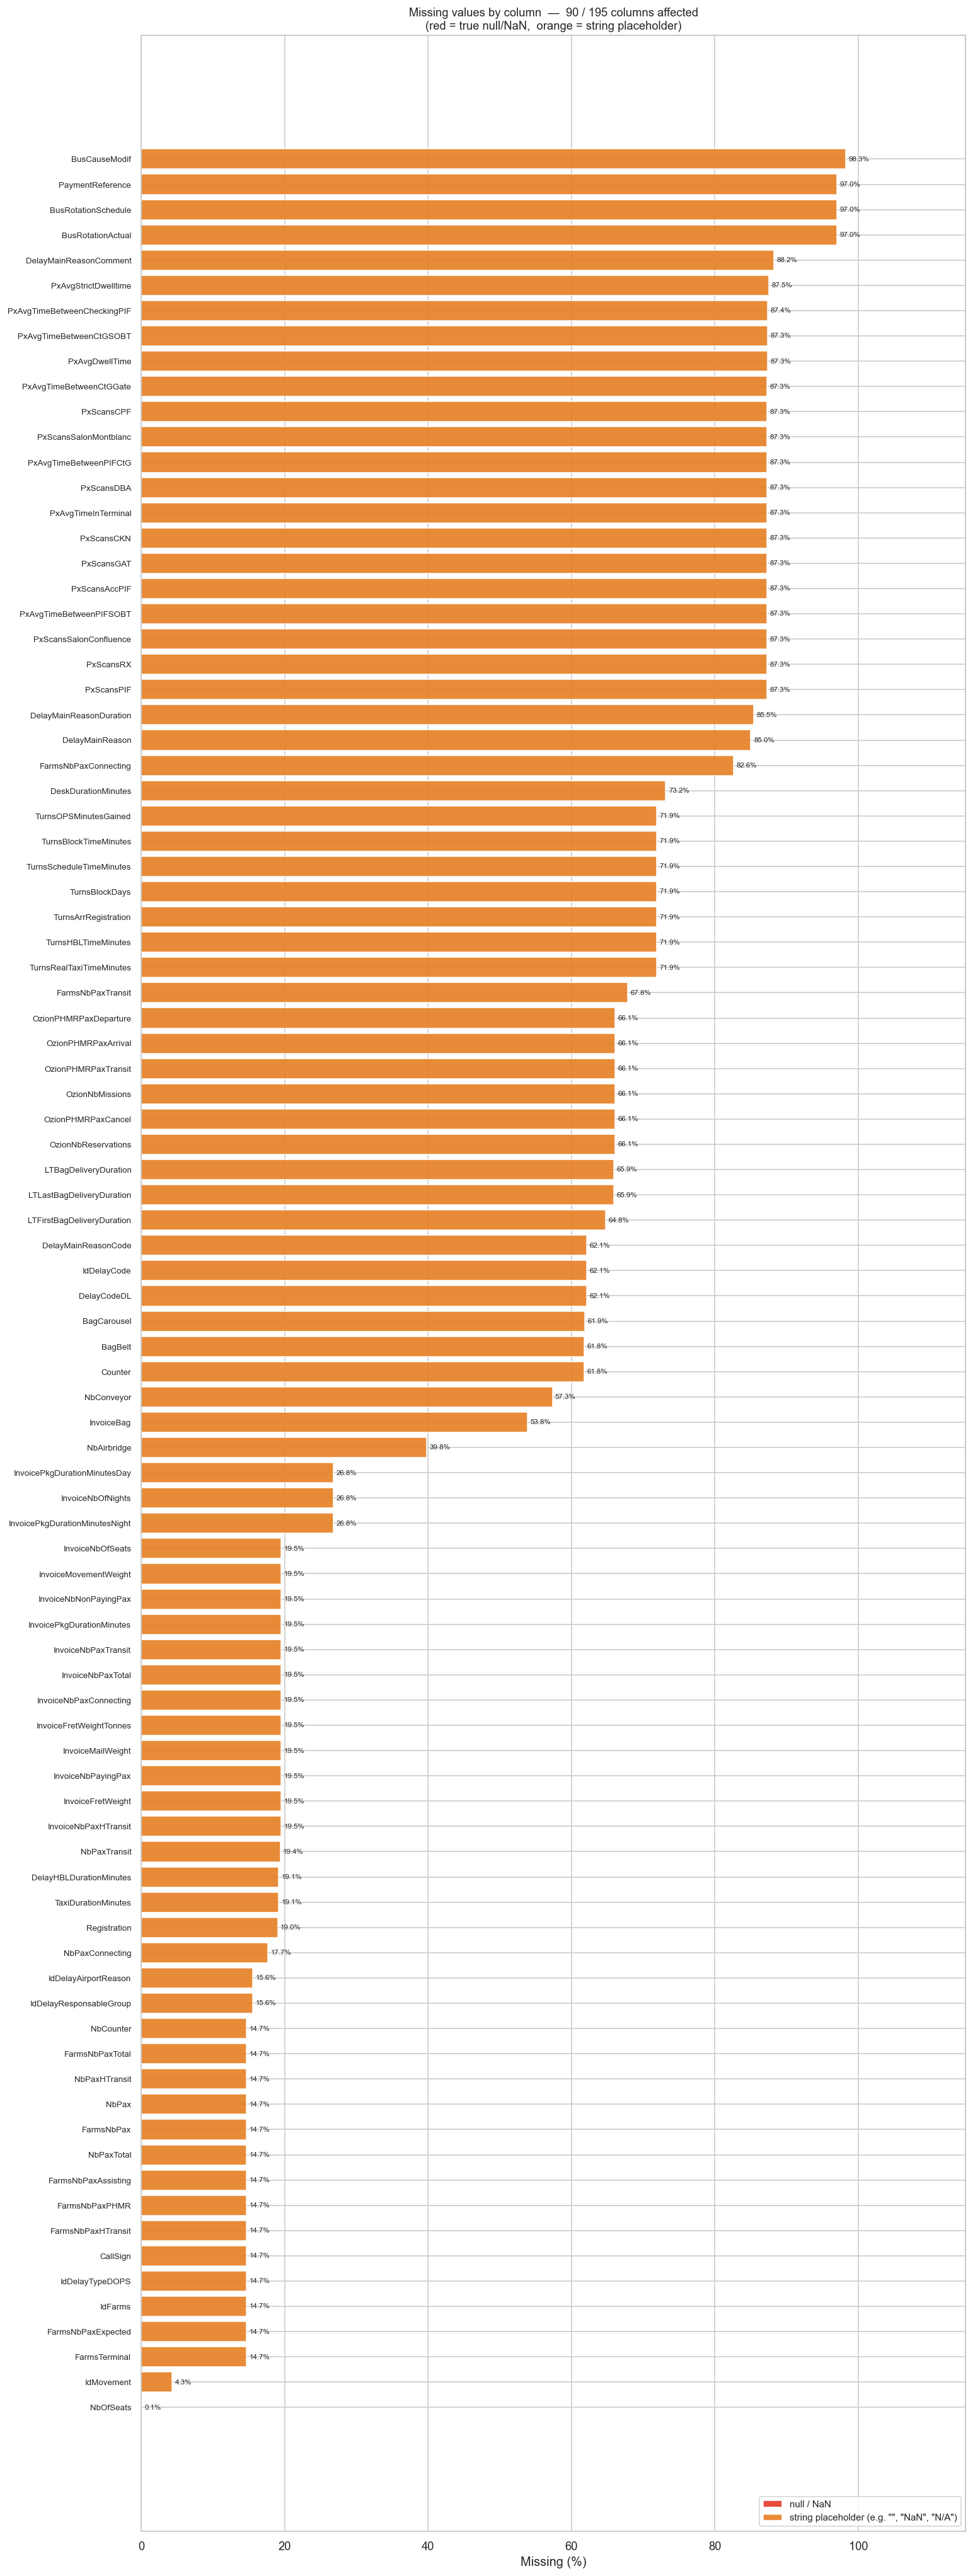

In [18]:

cols_with_missing = missing[missing['total_missing'] > 0].index.tolist()
n = len(cols_with_missing)

# ── Save full report to CSV ───────────────────────────────────────────────────
missing.to_csv(OUT_DIR / 'missing_report.csv')
print(f"Full missing report saved → {OUT_DIR / 'missing_report.csv'}")
print(f"Plotting {n} affected column(s) …\n")

# ── Chart ─────────────────────────────────────────────────────────────────────
fig_h = max(6, n * 0.38)
fig, ax = plt.subplots(figsize=(13, fig_h))

if cols_with_missing:
    plot_df  = missing.loc[cols_with_missing].sort_values('total_%')
    n_rows   = len(df_raw)
    null_pct = plot_df['null_count']  / n_rows * 100
    str_pct  = plot_df['str_missing'] / n_rows * 100

    ax.barh(plot_df.index, null_pct, color='#e74c3c', label='null / NaN')
    ax.barh(plot_df.index, str_pct, left=null_pct,
            color='#e67e22', alpha=0.9, label='string placeholder (e.g. "", "NaN", "N/A")')

    # Label each bar with total %
    for i, (idx, row) in enumerate(plot_df.iterrows()):
        ax.text(row['total_%'] + 0.4, i,
                f"{row['total_%']:.1f}%", va='center', fontsize=7)

    ax.set_xlabel('Missing (%)')
    ax.set_title(
        f'Missing values by column  —  {n} / {df_raw.shape[1]} columns affected\n'
        '(red = true null/NaN,  orange = string placeholder)',
        fontsize=11
    )
    ax.set_xlim(0, min(115, plot_df['total_%'].max() + 18))
    ax.tick_params(axis='y', labelsize=8)
    ax.legend(fontsize=9, loc='lower right')
else:
    ax.text(0.5, 0.5, 'No missing values detected!',
            ha='center', va='center', fontsize=14)
    ax.set_title('Missing values by column')

plt.tight_layout()
plt.savefig(OUT_DIR / '01_missing_values.png', bbox_inches='tight', dpi=150)
plt.show()


## 4. Duplicate rows

In [19]:
n_dup = df_raw.duplicated().sum()
print(f'Exact duplicate rows : {n_dup:,}  ({n_dup/len(df_raw)*100:.2f}%)')
if n_dup > 0:
    print('\nSample duplicates:')
    print(df_raw[df_raw.duplicated(keep=False)].head(6))

Exact duplicate rows : 0  (0.00%)


## 5. Dtype validation — numeric columns stored as string

In [20]:
print('Columns currently stored as object (string):')
obj_cols = df_raw.select_dtypes(include='object').columns.tolist()

results = []
for col in obj_cols:
    converted = pd.to_numeric(df_raw[col], errors='coerce')
    ok_pct = converted.notna().mean() * 100
    results.append({'column': col, 'parseable_as_numeric_%': round(ok_pct, 1)})

dtype_check = pd.DataFrame(results).sort_values('parseable_as_numeric_%', ascending=False)
print(dtype_check[dtype_check['parseable_as_numeric_%'] > 50].to_string(index=False))

Columns currently stored as object (string):
                        column  parseable_as_numeric_%
                     NbOfSeats                    99.9
               IdDelayTypeDOPS                    85.3
                     NbCounter                    85.3
                         NbPax                    85.3
                       IdFarms                    85.3
            FarmsNbPaxHTransit                    85.3
                    NbPaxTotal                    85.3
           FarmsNbPaxAssisting                    85.3
            FarmsNbPaxExpected                    85.3
                FarmsNbPaxPHMR                    85.3
               FarmsNbPaxTotal                    85.3
                    FarmsNbPax                    85.3
                 NbPaxHTransit                    85.3
          IdDelayAirportReason                    84.4
       IdDelayResponsableGroup                    84.4
               NbPaxConnecting                    82.3
           TaxiDurat

## 6. Invalid value checks

In [21]:
df = df_raw.copy()
df['LTScheduledDatetime'] = pd.to_datetime(df['LTScheduledDatetime'], errors='coerce')
df['NbPaxTotal'] = pd.to_numeric(df['NbPaxTotal'], errors='coerce')

print('=== Invalid / suspicious values ===')

# Dates
bad_dates = df['LTScheduledDatetime'].isna().sum()
print(f'\nUnparseable datetimes     : {bad_dates:,}')
if df['LTScheduledDatetime'].notna().any():
    print(f'  Date range              : {df["LTScheduledDatetime"].min().date()} → {df["LTScheduledDatetime"].max().date()}')

# NbPax
print(f'\nNbPaxTotal < 0            : {(df["NbPaxTotal"] < 0).sum():,}')
print(f'NbPaxTotal == 0           : {(df["NbPaxTotal"] == 0).sum():,}')
print(f'NbPaxTotal > 500 (>jumbo) : {(df["NbPaxTotal"] > 500).sum():,}')
print(f'NbPaxTotal missing        : {df["NbPaxTotal"].isna().sum():,}')

# Direction
if 'Direction' in df.columns:
    valid_dir = {'A', 'D', 'Arrival', 'Departure'}
    bad_dir = ~df['Direction'].isin(valid_dir) & df['Direction'].notna()
    print(f'\nUnexpected Direction values: {bad_dir.sum()}')
    if bad_dir.sum() > 0:
        print(df.loc[bad_dir, 'Direction'].value_counts().head())

# Hour range
if 'Hour' not in df.columns and df['LTScheduledDatetime'].notna().any():
    df['Hour'] = df['LTScheduledDatetime'].dt.hour
bad_hour = ~df['Hour'].between(0, 23) if 'Hour' in df.columns else pd.Series(dtype=bool)
print(f'\nHour outside 0-23         : {bad_hour.sum():,}')

=== Invalid / suspicious values ===

Unparseable datetimes     : 0
  Date range              : 2023-01-01 → 2026-10-25

NbPaxTotal < 0            : 0
NbPaxTotal == 0           : 33,882
NbPaxTotal > 500 (>jumbo) : 1
NbPaxTotal missing        : 53,587

Unexpected Direction values: 364623
Direction
Départ     182348
Arrivée    182275
Name: count, dtype: int64

Hour outside 0-23         : 0


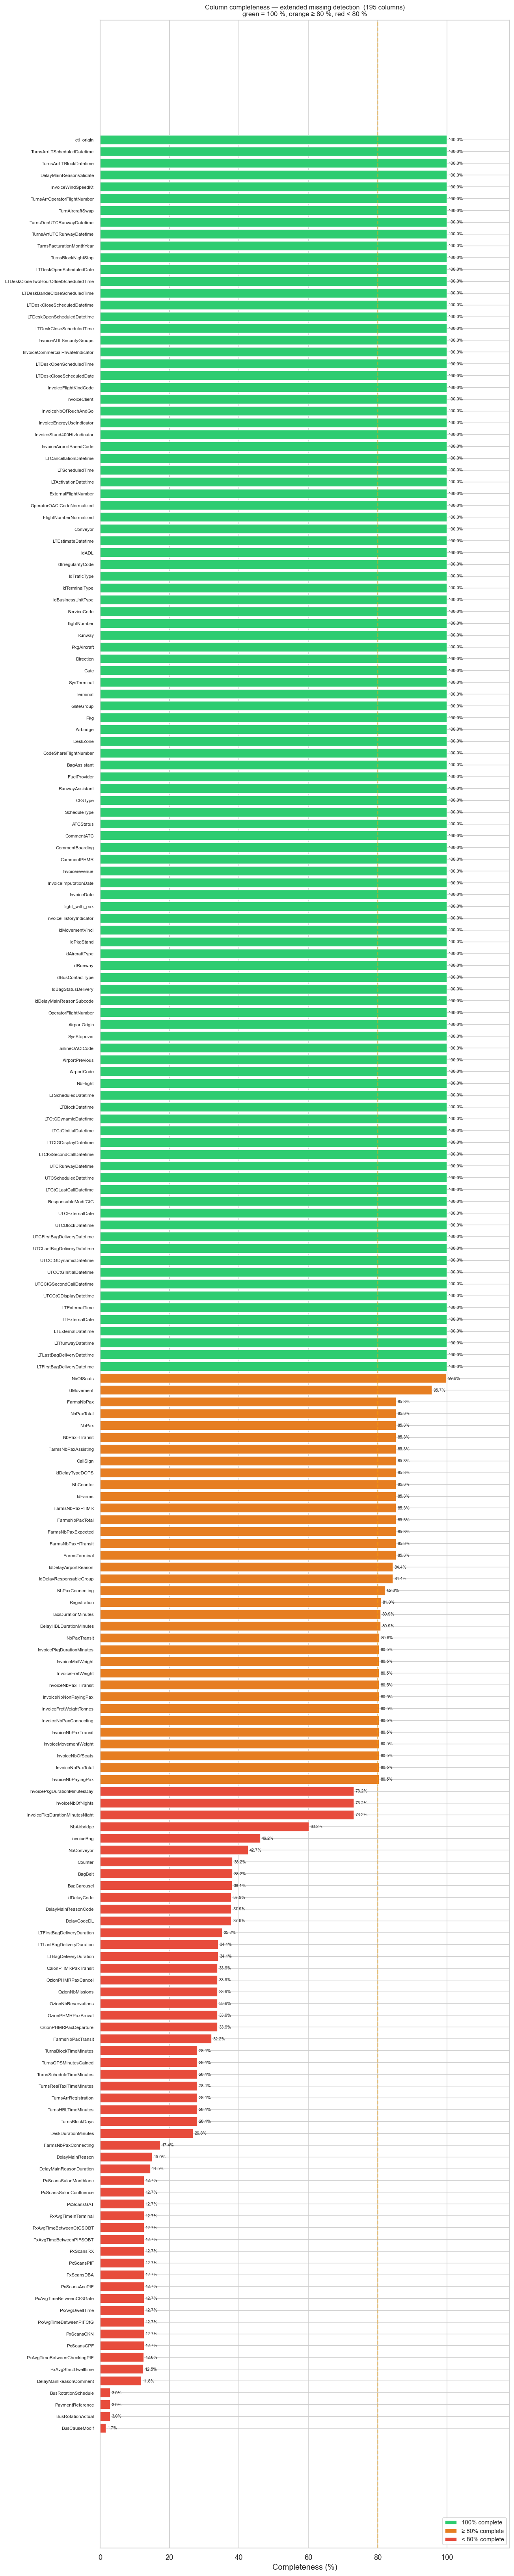

In [22]:

# Summary quality score per column — using extended missing detection
qdf = pd.DataFrame({
    'missing_%' : (ext_mask.sum() / len(df_raw) * 100).round(1),
    'unique'    : df_raw.nunique(),
    'dtype'     : df_raw.dtypes.astype(str),
})

completeness = (100 - qdf['missing_%']).sort_values()
n_cols = len(completeness)
fig_h  = max(8, n_cols * 0.28)

fig, ax = plt.subplots(figsize=(11, fig_h))
colors  = [
    '#2ecc71' if v == 100 else
    '#e67e22' if v >= 80  else
    '#e74c3c'
    for v in completeness
]
bars = ax.barh(completeness.index, completeness, color=colors)
ax.set_xlim(0, 118)
ax.tick_params(axis='y', labelsize=7)

for i, v in enumerate(completeness):
    ax.text(v + 0.4, i, f'{v:.1f}%', va='center', fontsize=6.5)

# Legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='100% complete'),
    Patch(facecolor='#e67e22', label='≥ 80% complete'),
    Patch(facecolor='#e74c3c', label='< 80% complete'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
ax.axvline(80, color='orange', linestyle='--', alpha=0.5)
ax.set_xlabel('Completeness (%)')
ax.set_title(
    f'Column completeness — extended missing detection  ({n_cols} columns)\n'
    'green = 100 %, orange ≥ 80 %, red < 80 %',
    fontsize=10
)

plt.tight_layout()
plt.savefig(OUT_DIR / '02_completeness.png', bbox_inches='tight', dpi=150)
plt.show()


## 7. Summary report

In [23]:

print('=' * 58)
print('DATA QUALITY SUMMARY  (extended missing detection)')
print('=' * 58)
print(f'Total rows                    : {len(df_raw):,}')
print(f'Total columns                 : {df_raw.shape[1]}')
print(f'Duplicate rows                : {df_raw.duplicated().sum():,}')
print()
print(f'Columns with ANY missing      : {(missing["total_missing"] > 0).sum()} / {df_raw.shape[1]}')
print(f'  – detected as null/NaN      : {(missing["null_count"] > 0).sum()} cols')
print(f'  – detected as string (only) : {((missing["str_missing"] > 0) & (missing["null_count"] == 0)).sum()} cols')
print(f'100%% complete columns         : {(missing["total_missing"] == 0).sum()}')
print(f'Rows with ANY missing value   : {ext_mask.any(axis=1).sum():,}  '
      f'({ext_mask.any(axis=1).mean()*100:.1f}%%)')
print()

# Top-10 worst columns
print('Top-10 columns by total missing %%:')
print(f"  {'Column':<38} {'null':>7} {'str_NA':>7} {'total':>7} {'total_%%':>8}")
print('  ' + '-' * 65)
for col, row in missing.head(10).iterrows():
    print(f"  {col:<38} {row['null_count']:>7,} {row['str_missing']:>7,} "
          f"{row['total_missing']:>7,} {row['total_%']:>7.1f}%%")

print()
pax = pd.to_numeric(df_raw.get('NbPaxTotal', pd.Series()), errors='coerce')
print(f'NbPaxTotal missing            : {pax.isna().sum():,}  ({pax.isna().mean()*100:.1f}%%)')
print(f'NbPaxTotal zero/negative      : {(pax <= 0).sum():,}  ({(pax<=0).mean()*100:.1f}%%)')
print()
print(f'Full missing report saved → {OUT_DIR / "missing_report.csv"}')
print('=' * 58)


DATA QUALITY SUMMARY  (extended missing detection)
Total rows                    : 364,623
Total columns                 : 195
Duplicate rows                : 0

Columns with ANY missing      : 90 / 195
  – detected as null/NaN      : 0 cols
  – detected as string (only) : 90 cols
100%% complete columns         : 105
Rows with ANY missing value   : 364,623  (100.0%%)

Top-10 columns by total missing %%:
  Column                                    null  str_NA   total total_%%
  -----------------------------------------------------------------
  BusCauseModif                              0.0 358,297.0 358,297.0    98.3%%
  PaymentReference                           0.0 353,748.0 353,748.0    97.0%%
  BusRotationSchedule                        0.0 353,752.0 353,752.0    97.0%%
  BusRotationActual                          0.0 353,750.0 353,750.0    97.0%%
  DelayMainReasonComment                     0.0 321,729.0 321,729.0    88.2%%
  PxAvgStrictDwelltime                       0.0 319,143